<a href="https://colab.research.google.com/github/bernaldiaz/bernaldiaz/blob/main/metodo_de_heun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Se trata de resolver esta ecuacion $ ax'''​+ax¨+bx˙+cx=sin(t)$ por el metodo de Heun

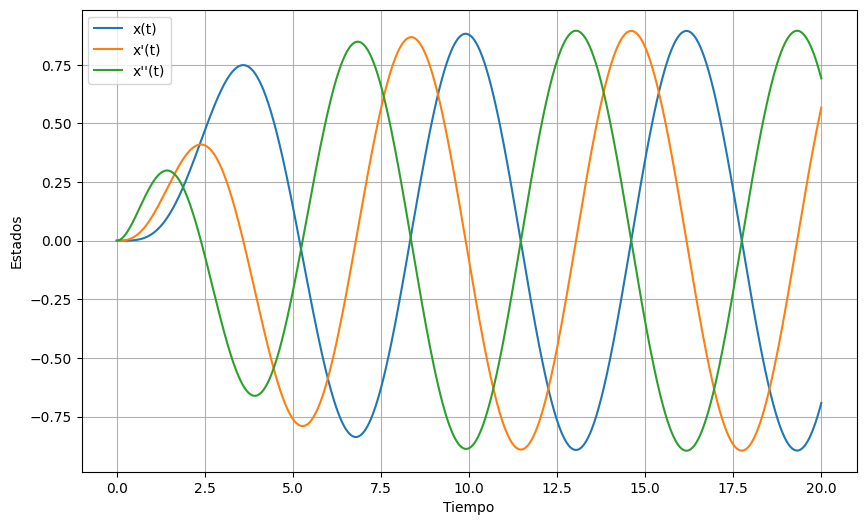

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del sistema
a = 1.5
b = 2.0
c = 1.0

# Definición del sistema
def rates(t, f):
    x1, x2, x3 = f

    Dx1 = x2
    Dx2 = x3
    Dx3 = np.sin(t) - a*x3 - b*x2 - c*x1

    return np.array([Dx1, Dx2, Dx3])

# Parámetros de integración
h = 0.01
t0 = 0.0
tf = 20.0
N = int((tf - t0)/h)

# Vectores de tiempo y solución
t = np.zeros(N+1)
f = np.zeros((N+1, 3))

# Condiciones iniciales
t[0] = t0
f[0] = [0.0, 0.0, 0.0]

# Método de Heun
for n in range(N):
    # Paso predictor (Euler)
    k1 = rates(t[n], f[n])
    f_pred = f[n] + h * k1

    # Paso corrector
    k2 = rates(t[n] + h, f_pred)
    f[n+1] = f[n] + (h/2) * (k1 + k2)
    t[n+1] = t[n] + h

# Gráficas
plt.figure(figsize=(10,6))
plt.plot(t, f[:,0], label="x(t)")
plt.plot(t, f[:,1], label="x'(t)")
plt.plot(t, f[:,2], label="x''(t)")
plt.xlabel("Tiempo")
plt.ylabel("Estados")
plt.legend()
plt.grid()
plt.show()
